### Assignment 2

MohammadMahdi Shokrzadeh 402101985


### Dataset Explanation

We utilizes the [House Data dataset from Kaggle](https://www.kaggle.com/datasets/shree1992/housedata?select=data.csv) to explore and predict property prices. The dataset consists of a large collection of actual real estate sales records containing various structural and location-based features.




### Data Exploration

In [469]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

# Feature engineering / selection
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.decomposition import PCA

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_ridge import KernelRidge

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Regression metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

# Classification metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)




sns.set_theme(style="whitegrid")
df = pd.read_csv('data.csv')
pd.set_option('display.max_columns', None)
print(f"Shape: {df.shape}")
print(f"\nCity distribution:\n{df['city'].value_counts()}")
print(f"\nView values: {sorted(df['view'].unique())}")
print(f"\nCondition values: {sorted(df['condition'].unique())}")
print(f"\nMissing values:\n{df.isnull().sum()}")
display(df.head())

n_rows = df.shape[0]
print(f"\nSample size: {n_rows} rows")

city_counts = df['city'].value_counts()
n_cities = len(city_counts)
print(f"\n Cities: {n_cities} unique cities")
print(f"  Top 5 cities:\n{city_counts.head()}")

view_counts = df['view'].value_counts().sort_index()
print(f"\n View ratings: {view_counts.to_dict()}")
waterfront_dist = df['waterfront'].value_counts()
print(f"\nWaterfront distribution:\n{waterfront_dist}")
minority_pct = waterfront_dist.min() / waterfront_dist.sum() * 100
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(f"\nMissing values:\n{missing_pct[missing_pct > 0]}")
zero_prices = (df['price'] == 0).sum()
print(f"\nNumber of properties with price $0: {zero_prices}")



Shape: (4600, 18)

City distribution:
city
Seattle                1573
Renton                  293
Bellevue                286
Redmond                 235
Issaquah                187
Kirkland                187
Kent                    185
Auburn                  176
Sammamish               175
Federal Way             148
Shoreline               123
Woodinville             115
Maple Valley             96
Mercer Island            86
Burien                   74
Snoqualmie               71
Kenmore                  66
Des Moines               58
North Bend               50
Covington                43
Duvall                   42
Lake Forest Park         36
Bothell                  33
Newcastle                33
SeaTac                   29
Tukwila                  29
Vashon                   29
Enumclaw                 28
Carnation                22
Normandy Park            18
Clyde Hill               11
Medina                   11
Fall City                11
Black Diamond             9
Raven

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA



Sample size: 4600 rows

 Cities: 44 unique cities
  Top 5 cities:
city
Seattle     1573
Renton       293
Bellevue     286
Redmond      235
Issaquah     187
Name: count, dtype: int64

 View ratings: {0: 4140, 1: 69, 2: 205, 3: 116, 4: 70}

Waterfront distribution:
waterfront
0    4567
1      33
Name: count, dtype: int64

Missing values:
Series([], dtype: float64)

Number of properties with price $0: 49


Based on data exploration, we need to fix that $0$ price issues.In a market, houses are not sold for $\$0$. These entries are almost certainly data collection errors, missing values recorded as zeros, or non-market transfers (like passing a deed to a family member). 
So we will drop them, while we can fill in missing *features* with means or medians, we want the model to learn from ground truth, not our filled in data. Since 49 rows is only about $1\%$ of the dataset, dropping them seems to be the safest and most mathematically sound approach.

In [470]:
df = df[df['price'] > 0]


### EDA & Some Visualization

e:\Program Files\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


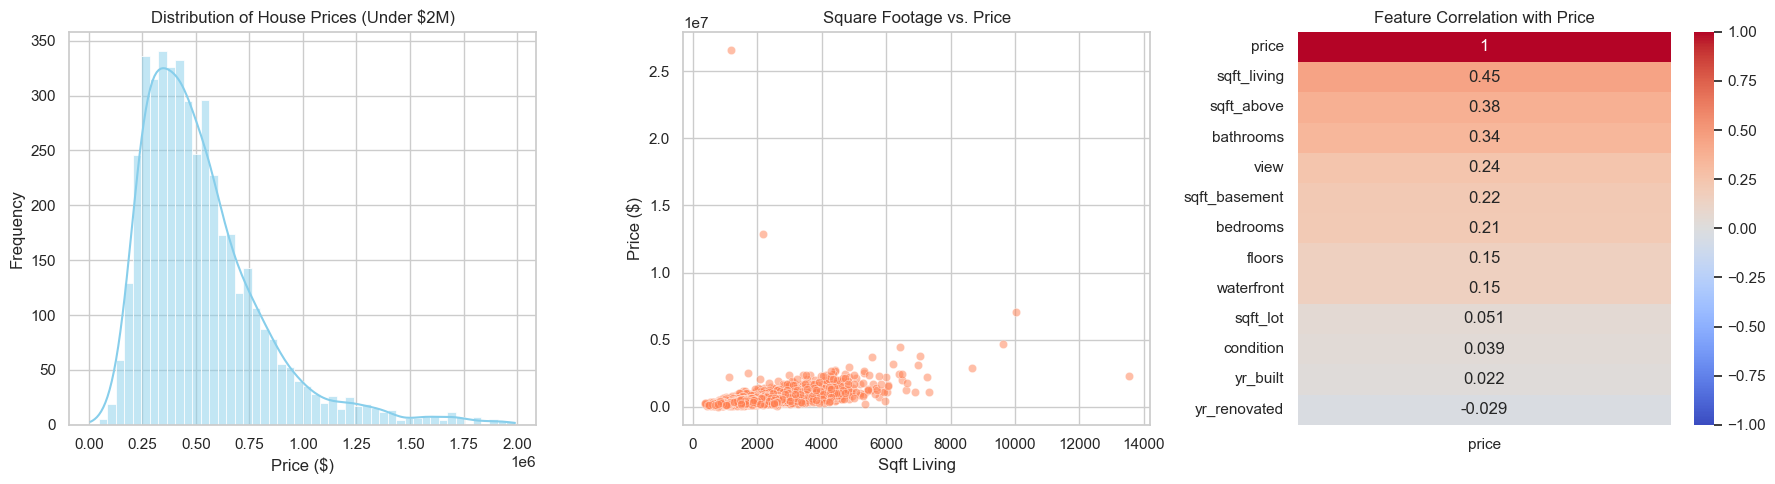

In [471]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df[df['price'] < 2000000]['price'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of House Prices (Under $2M)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

sns.scatterplot(x='sqft_living', y='price', data=df, alpha=0.5, ax=axes[1], color='coral')
axes[1].set_title('Square Footage vs. Price')
axes[1].set_xlabel('Sqft Living')
axes[1].set_ylabel('Price ($)')

num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()
sns.heatmap(corr_matrix[['price']].sort_values(by='price', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title('Feature Correlation with Price')

plt.tight_layout()
plt.show()


### Part 1
Before training, we need to handle categorical features (like city), drop irrelevant columns (like street and date), and scale our numerical features so regularization methods (Ridge/LASSO) work correctly.
the following block prepares the data for model. We drop columns that are too granular or irrelevant (`street`, `date`, `statezip`, `country`). We then use a `ColumnTransformer` to standardize numerical features (mean of $0$, variance of $1$) and One-Hot Encode the `city` column. Finally, we split the data into $80\%$ training and $20\%$ testing sets.


In [472]:
X = df.drop(columns=['price', 'date', 'street', 'statezip', 'country']) 
y = df['price']

num_cols = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
            'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 
            'yr_built', 'yr_renovated']
cat_cols = ['city']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (3640, 54)
Testing data shape: (911, 54)


To avoid repeating code, this function takes the model's predictions, calculates the required evaluation metrics (MSE, MAE, MAPE, $R^2$), and saves them into a dictionary for later comparison. It also generates a scatter plot comparing the actual prices against the predicted prices. The red dashed line represents perfect predictions.


In [473]:
results = {}

def evaluate_and_plot(model_name, y_true, y_pred):
    """Calculates metrics and plots actual vs predicted values."""
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    results[model_name] = {'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R2': r2}
    
    print(f"--- {model_name} Performance ---")
    print(f"MSE:  {mse:,.2f}")
    print(f"MAE:  {mae:,.2f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R²:   {r2:.4f}\n")
    
    plt.figure(figsize=(8, 5))
    plt.scatter(y_true, y_pred, alpha=0.3, color='blue')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.tight_layout()
    plt.show()


Here we will train three fundamental regression models:
*   **Linear Regression:** Fits a standard line/hyperplane.As we know, it is prone to overfitting if there are many features.
*   **Ridge Regression:** Adds an L2 penalty (sum of squared coefficients) to the loss function. This shrinks the coefficients of less important features, preventing overfitting and handling multicollinearity well.
*   **LASSO Regression:** Adds an L1 penalty (sum of absolute coefficients). This not only prevents overfitting but acts as a feature selector by pushing the coefficients of useless features to exactly $0$.


--- Linear Regression Performance ---
MSE:  24,642,413,988,586,336,255,992,165,040,128.00
MAE:  232,593,425,235,794.50
MAPE: 429742293.8130
R²:   -165640581264031875072.0000



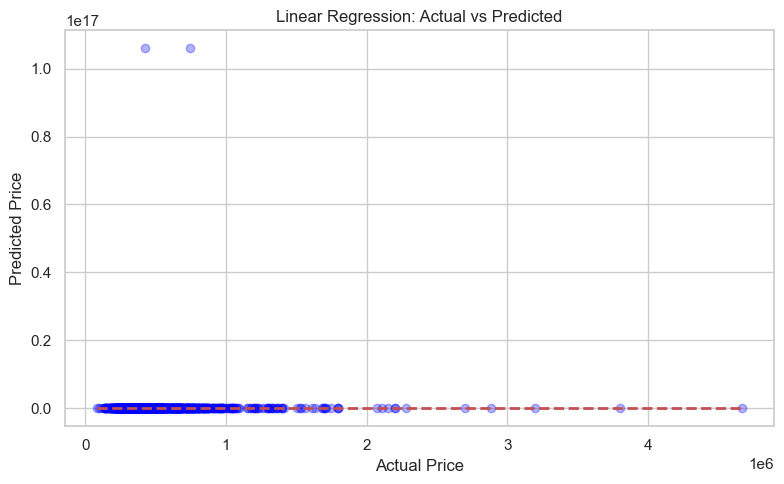

--- Ridge Regression Performance ---
MSE:  47,312,258,705.81
MAE:  130,746.46
MAPE: 0.2873
R²:   0.6820



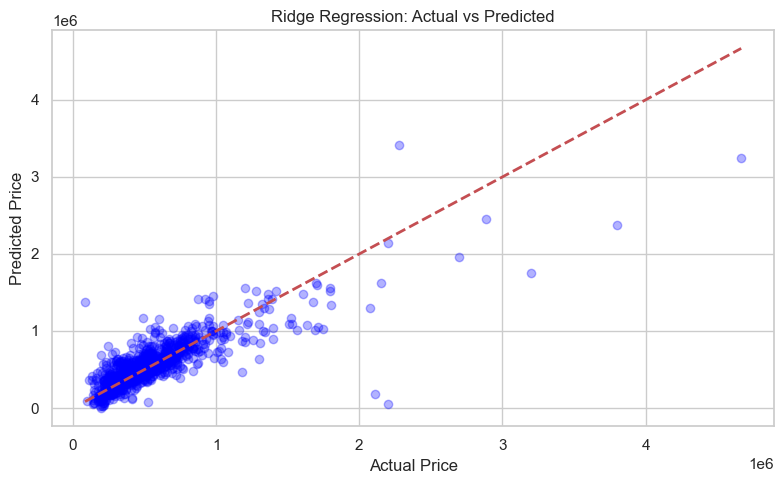

--- LASSO Regression Performance ---
MSE:  47,358,828,892.60
MAE:  130,473.29
MAPE: 0.2880
R²:   0.6817



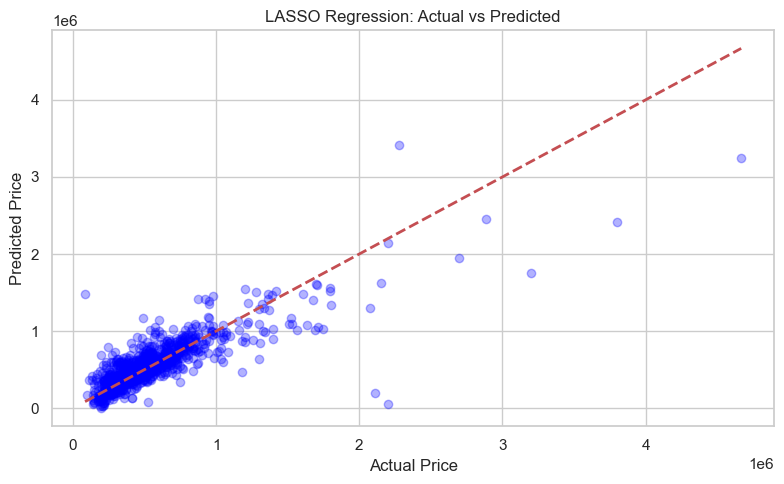

In [474]:
#  Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
evaluate_and_plot("Linear Regression", y_test, y_pred_lr)

#  Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
evaluate_and_plot("Ridge Regression", y_test, y_pred_ridge)

#  LASSO Regression 
lasso_model = Lasso(alpha=100.0, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)
evaluate_and_plot("LASSO Regression", y_test, y_pred_lasso)


Standard Linear, Ridge, and LASSO models assume the relationship between features and the target is linear. However, house prices often can have non-linear relationships (e.g., the value of square footage might scale differently in different cities!)  
As we know The Kernel Trick solves this by implicitly mapping the original input features into a higher-dimensional space where the relationship *does* become linear. It calculates the dot products between data points in this higher-dimensional space using a "Kernel Function" (like the RBF/Gaussian kernel used above) without ever actually computing the expensive mathematical transformation. 
So it allows a model to capture highly complex, non-linear patterns in the data while still utilizing the robust mathematical framework of linear regression, generally leading to higher $R^2$ scores and lower errors on complex datasets. So we used it as:

--- Kernel Regression Performance ---
MSE:  40,268,652,152.07
MAE:  120,869.79
MAPE: 0.2576
R²:   0.7293



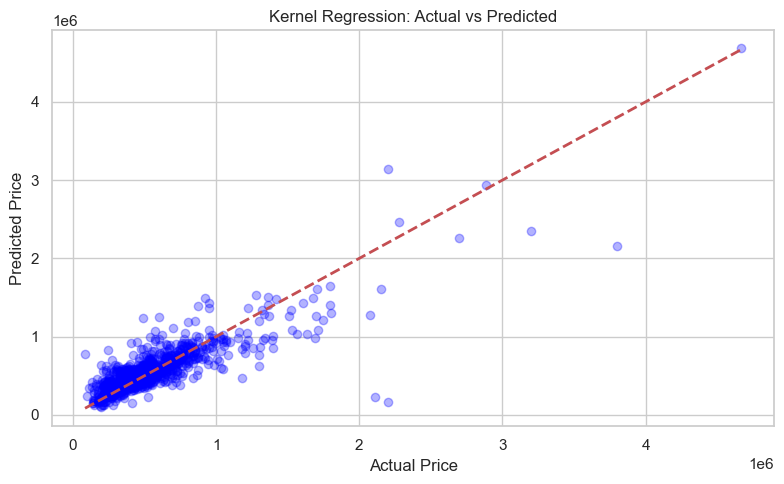

In [475]:
# Kernel Regression (using Kernel Ridge with RBF kernel)
kr_model = KernelRidge(kernel='rbf', alpha=0.12, gamma=0.003)
kr_model.fit(X_train_scaled, y_train)
y_pred_kr = kr_model.predict(X_test_scaled)
evaluate_and_plot("Kernel Regression", y_test, y_pred_kr)


This final block takes all the metrics calculated during the training phase and plots them side-by-side. 
The left chart shows the  MAE,
The right chart shows the $R^2$ Score

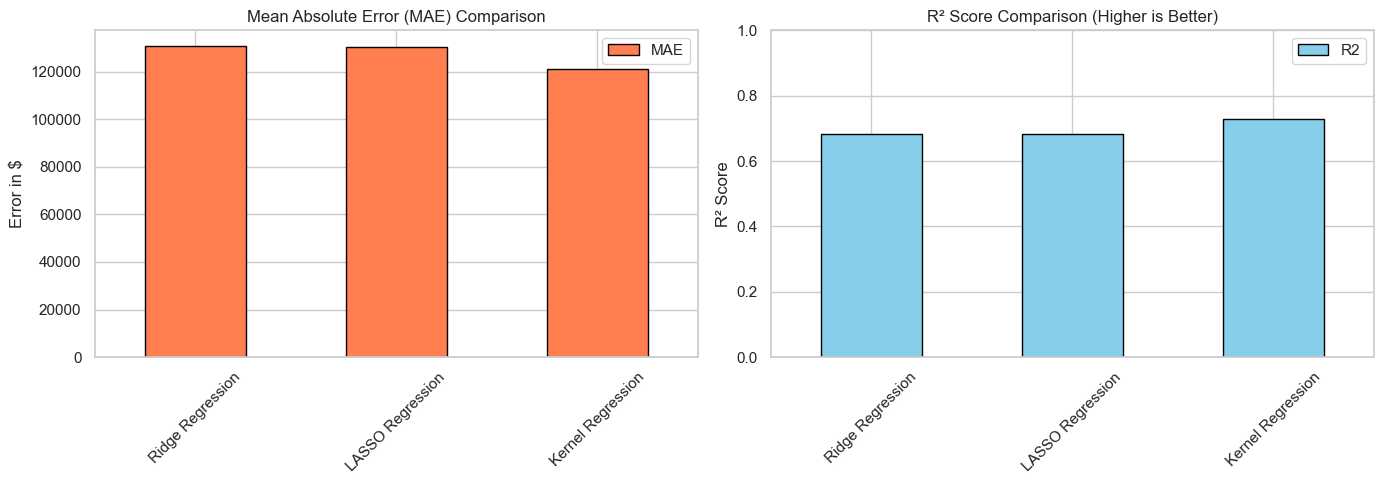

,MSE,MAE,MAPE,R2
Ridge Regression,4.731226e+10,130746.457317,0.287340,0.681978
LASSO Regression,4.735883e+10,130473.286381,0.288002,0.681665
Kernel Regression,4.026865e+10,120869.789592,0.257641,0.729323


In [476]:
results_df = pd.DataFrame(results).T
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# we plot all except of linear regression, becuase that had terrible output and will create issue 
# with the graph scales!
results_df = results_df.drop(index='Linear Regression')
results_df[['MAE']].plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Mean Absolute Error (MAE) Comparison')
axes[0].set_ylabel('Error in $')
axes[0].tick_params(axis='x', rotation=45)

results_df[['R2']].plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('R² Score Comparison (Higher is Better)')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
display(results_df)



### Result Explanations

*   **Linear Regression:** Utter failure. R² is $-1.65 \times 10^{20}$, MAE is astronomical, and the plot shows predictions flying off into the $10^{17}$ range. This is because of multicollinearity and overfitting caused by One-Hot Encoding without regularization. The standard linear model couldn't handle the high number of sparse `city` columns, resulting in coefficients that exploded. When it encountered new data in the test set, it predicted massive, nonsensical numbers.
*   **Ridge & LASSO Results:** It did well. Both achieved an R² of approximately $0.68$ and an MAE of roughly $\$130,000$.  Regularization saved the model. By applying a penalty to the size of the coefficients, Ridge and LASSO prevented the `city` columns from blowing up the model. Both models learned the underlying patterns well, as seen in their scatter plots where the predicted prices closely hug the red dashed line (actual price) for houses under $\$1.5$ million.

*  **Kernel Regression**
It was Decent and slightly better than others. The RBF kernel avoided the catastrophic failure of standard Linear Regression by using L2 regularization (Ridge) within its high-dimensional mapping.

Also if we look at the scatter plots for Ridge, LASSO, and Kernel regression, the models are highly accurate for houses clustered between $\$0$ and $\$1.5 \times 10^6$. However, they all struggle with extreme outliers (the actual prices in the $\$3 \times 10^6$ to $\$4 \times 10^6$ range). The models severely under-predict these luxury properties. This seems normal; luxury homes often have unmeasured intrinsic values that aren't perfectly captured by square footage and bed/bath counts alone.




### Discussion Questions Of Part 1

**1. Choose the best regression metric for our dataset and justify.**

The best metric for this housing dataset is Mean Absolute Error. 
House price datasets naturally contain extreme outliers (e.g., luxury mansions). Metrics like Mean Squared Error square the errors, meaning they disproportionately penalize the model for being wrong about a $\$4$ million house compared to a $\$300,000$ house. MAE provides a linear penalty, giving a much more interpretable result: for exmple: "On average, our model's predictions are off by $\$X$." 

**2. Explain when each regression model is preferable.**
*   **Linear Regression:** Preferable as a simple baseline when there is a clear linear relationship between variables and no multicollinearity (which was completely violated by our One-Hot Encoded `city` column).
*   **Ridge Regression (L2):** Preferable when we have a high number of features or multicollinearity (like dummy variables). It shrinks coefficients to prevent overfitting but keeps all features in the model.
*   **LASSO Regression (L1):** Preferable when we have many redundant or useless features. It performs implicit feature selection by forcing the coefficients of unimportant features exactly to $0$, resulting in a simpler, more interpretable model.
*   **Kernel Regression:** Preferable when the relationship between features and the target is highly non-linear, and we have a small to medium-sized dataset (it becomes computationally expensive on very large datasets).

**3. Briefly explain the kernel trick in a few sentences and how it can help achieve better regression results. Did we use any kernel trick?**
The kernel trick is a mathematical technique that allows models to implicitly map input data into a much higher-dimensional space without actually having to compute the exact coordinates of the data in that new space. By doing this, complex, non-linear patterns in the original data become linearly separable or linearly predictable in the higher-dimensional space. This helps achieve better regression results by allowing fundamentally linear models to capture intricate, non-linear relationships. 
we used it when we implemented `KernelRidge` with `kernel='rbf'` (Radial Basis Function).


## Section 2

For this section, we will create a derived binary target: **`is_expensive`**. We will classify houses as expensive ($1$) if their price is above the median, and not expensive ($0$) if below.



 Here we create the `is_expensive` target. We drop irrelevant columns and the original `price` column to prevent data leakage. We then scale numerical features and One-Hot encode the categorical `city` column, splitting the data into $80\%$ training and $20\%$ testing sets.

In [477]:
data = pd.read_csv('data.csv')
data = data[data['price'] > 0].copy()

median_price = data['price'].median()
data['is_expensive'] = (data['price'] > median_price).astype(int)

X = data.drop(columns=['price', 'is_expensive', 'date', 'street', 'statezip', 'country'])
y = data['is_expensive']
categorical_cols = ['city']
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")


X_train_scaled shape: (3640, 54)


and here we calculate the required metrics (Accuracy, Precision, Recall, F1-Score) and extracts probabilities to compute the ROC Curve and AUC.

In [478]:

class_results = {}

def evaluate_classifier(model_name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    class_results[model_name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': roc_auc}
    
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC:       {roc_auc:.4f}\n")
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Expensive', 'Expensive']).plot(ax=ax[0], cmap='Blues', colorbar=False)
    ax[0].set_title(f'{model_name} - Confusion Matrix')
    
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title(f'{model_name} - ROC Curve')
    ax[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()


We train standard Logistic Regression and a Support Vector Machine using a linear kernel. SVMs require `probability=True` to allow us to calculate the ROC AUC metric, as they output decision boundaries by default rather than raw probabilities:

--- Logistic Regression ---
Accuracy:  0.8562
Precision: 0.8705
Recall:    0.8423
F1-Score:  0.8562
AUC:       0.9350



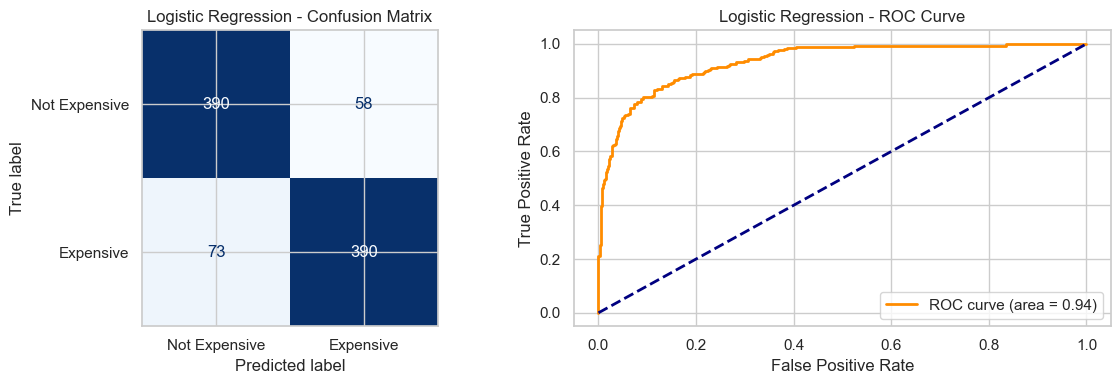

--- Linear SVM ---
Accuracy:  0.8441
Precision: 0.8639
Recall:    0.8229
F1-Score:  0.8429
AUC:       0.9340



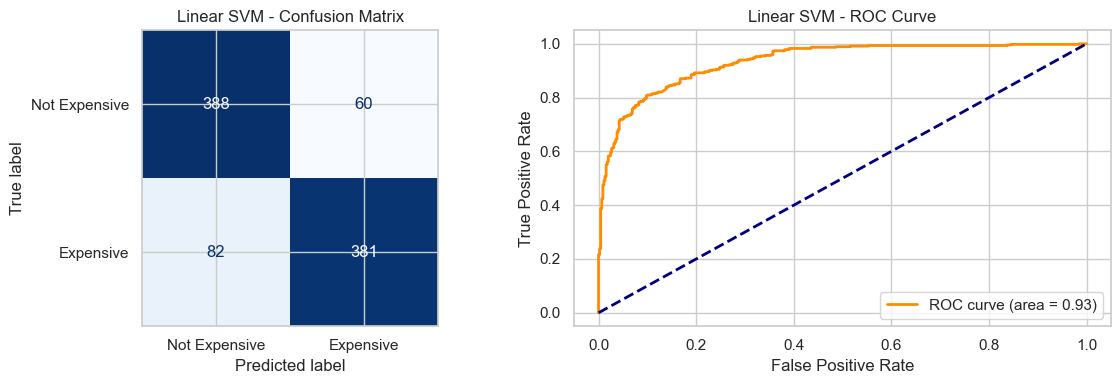

In [479]:


# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
lr_preds = log_reg.predict(X_test_scaled)
lr_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

evaluate_classifier("Logistic Regression", y_test, lr_preds, lr_probs)

#  Linear SVM
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
svm_lin_preds = svm_linear.predict(X_test_scaled)
svm_lin_probs = svm_linear.predict_proba(X_test_scaled)[:, 1]

evaluate_classifier("Linear SVM", y_test, svm_lin_preds, svm_lin_probs)


Here we apply the kernel trick to classification. The `rbf` kernel maps the house features into a higher-dimensional space to find a non-linear decision boundary separating expensive and non-expensive houses.

--- Kernel SVM (RBF) ---
Accuracy:  0.8364
Precision: 0.8584
Recall:    0.8121
F1-Score:  0.8346
AUC:       0.9237



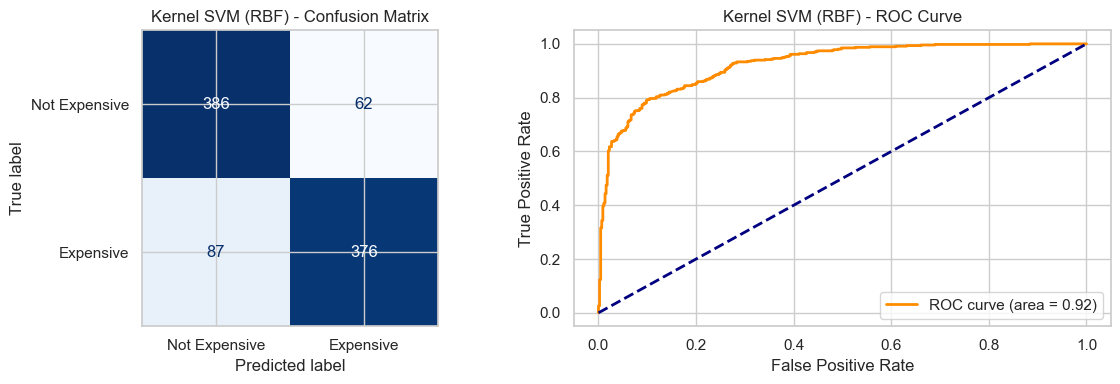

In [480]:
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
svm_rbf_preds = svm_rbf.predict(X_test_scaled)
svm_rbf_probs = svm_rbf.predict_proba(X_test_scaled)[:, 1]

evaluate_classifier("Kernel SVM (RBF)", y_test, svm_rbf_preds, svm_rbf_probs)


KNN relies on finding the $K$ closest points to make a prediction. We use `GridSearchCV` to automatically test multiple values for $K$ ($3$ through $15$) using 5-fold cross-validation. We then evaluate the model using the optimal $K$ value it discovered.

Best K found for KNN: 5
--- KNN (K=5) ---
Accuracy:  0.8200
Precision: 0.8215
Recall:    0.8251
F1-Score:  0.8233
AUC:       0.8948



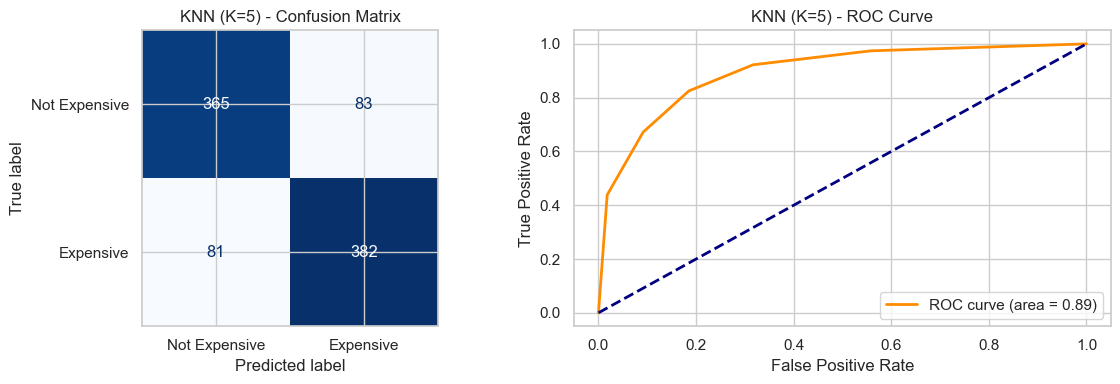

In [481]:

knn = KNeighborsClassifier()
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)

best_k = grid_knn.best_params_['n_neighbors']
print(f"Best K found for KNN: {best_k}")

best_knn = grid_knn.best_estimator_
knn_preds = best_knn.predict(X_test_scaled)
knn_probs = best_knn.predict_proba(X_test_scaled)[:, 1]

evaluate_classifier(f"KNN (K={best_k})", y_test, knn_preds, knn_probs)


Unconstrained Decision Trees will overfit the training data by creating a node for nearly every sample. We tune `max_depth` to prevent this. Finally, we train a Random Forest, which is an ensemble of many decision trees. Random Forests generally perform exceptionally well out-of-the-box on tabular data and rarely overfit as severely as single trees.

Best max_depth found for Decision Tree: 7
--- Decision Tree (Depth=7) ---
Accuracy:  0.8145
Precision: 0.7988
Recall:    0.8488
F1-Score:  0.8230
AUC:       0.8696



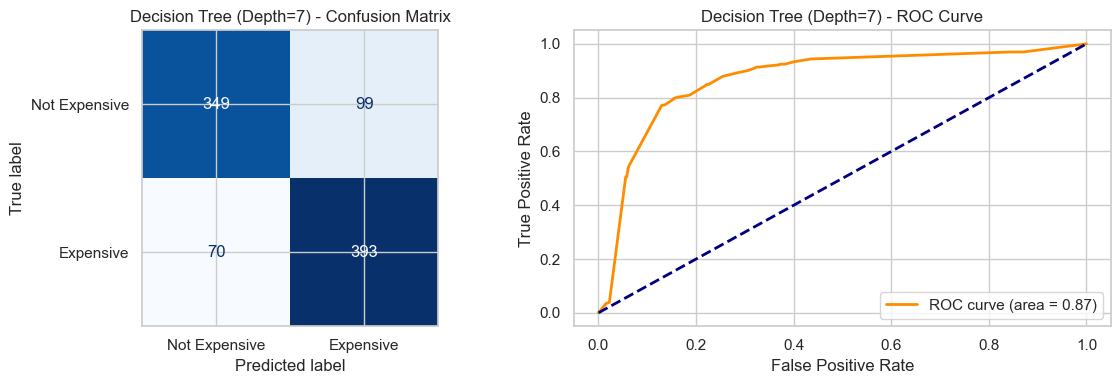

--- Random Forest ---
Accuracy:  0.8705
Precision: 0.8842
Recall:    0.8575
F1-Score:  0.8706
AUC:       0.9301



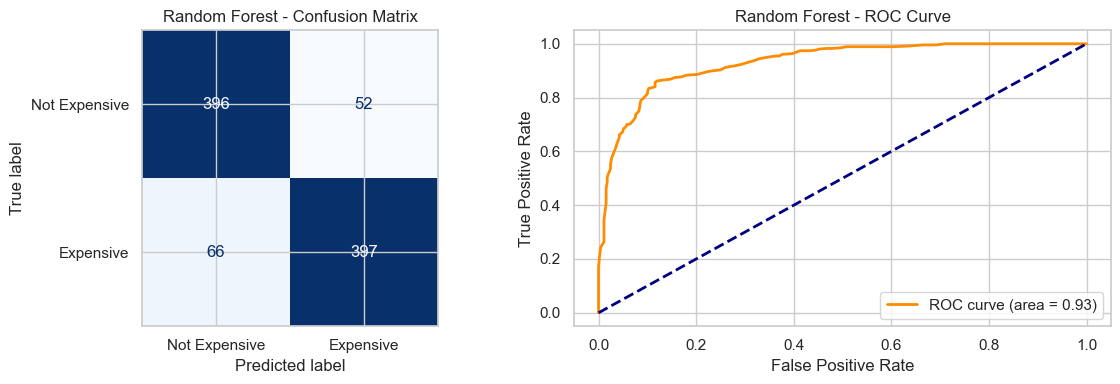

In [482]:

dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {'max_depth': [3, 5, 7, 10, None]}

grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train_scaled, y_train)

best_depth = grid_dt.best_params_['max_depth']
print(f"Best max_depth found for Decision Tree: {best_depth}")

best_dt = grid_dt.best_estimator_
dt_preds = best_dt.predict(X_test_scaled)
dt_probs = best_dt.predict_proba(X_test_scaled)[:, 1]

evaluate_classifier(f"Decision Tree (Depth={best_depth})", y_test, dt_preds, dt_probs)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]

evaluate_classifier("Random Forest", y_test, rf_preds, rf_probs)

### Result Explanation

**Logistic Regression & Linear SVM**
*   **Logistic Regression:** This was one of the best-performing models overall. It achieved an Accuracy of $85.62\%$ with AUC of $0.9350$. it correctly predicted exactly $390$ Not Expensive houses and $390$ Expensive houses, making roughly the same number of errors in both directions ($58$ False Positives, $73$ False Negatives). 
*   **Linear SVM:** Performed almost identically to Logistic Regression, with an Accuracy of $84.41\%$ and an AUC of $0.9340$. The strong performance of these two models indicates that after One-Hot Encoding the `city` column and scaling the features, the data is highly linearly separable. A simple straight hyperplane does an excellent job of dividing cheap vs. expensive houses :)

**Kernel SVM (RBF)**
*    The RBF Kernel SVM achieved an Accuracy of $83.64\%$ and an AUC of $0.9237$.
**K-Nearest Neighbors (KNN)**
*   The Grid Search found the optimal neighbors to be $K=5$. The model achieved an Accuracy of $82.00\%$ and an AUC of $0.8948$. KNN performed the worst out of the group. This might be expected due to the Curse of Dimensionality. Because we One-Hot Encoded the cities, our dataset has $54$ features. KNN calculates distance based on all features equally; in high-dimensional spaces, the concept of "distance" becomes diluted, making it harder for KNN to find truly "similar" neighbors.

**Decision Tree & Random Forest**
*   **Decision Tree:** With an optimal `max_depth` of $7$, the Decision Tree achieved an Accuracy of $81.45\%$ and an AUC of $0.8696$. While it performed well, it had the lowest AUC of all models, struggling to generalize as effectively as the linear or ensemble methods.
*   **Random Forest:** This model achieved the highest overall Accuracy ($87.05\%$) and F1-Score ($0.8706$), alongside a very strong AUC of $0.9301$ :). By aggregating multiple decision trees, the Random Forest successfully reduced the variance and overfitting typically seen in single trees. It captured complex feature interactions perfectly without sacrificing generalization, making it the most accurate model for this dataset.


### Discussion Questions

**1. Choose the best classification metric for our dataset and justify.**

For this specific dataset, **Accuracy** and **AUC** are the best metrics. 
Normally, in housing datasets (like predicting if a house is on the waterfront), the classes are highly imbalanced, making Accuracy misleading and forcing us to use F1-Score. However, because we explicitly defined our target using the **median price**, our dataset is forced to have an exact $50/50$ balance.  AUC is also excellent here as it evaluates how well the model separates the two classes across all probability thresholds.

**2. Explain 3 techniques to regularize the training process for decision trees.**

Unconstrained decision trees will grow until every leaf is pure, leading to massive overfitting. we can regularize them using:
1.  **Maximum Depth:** Restricts how many splits deep the tree can grow. This stops the tree from memorizing highly specific, complex patterns in the training data that won't generalize.
2.  **Minimum Samples per Leaf:** Requires a minimum number of data points to exist in a final leaf node. This prevents the tree from creating a split just to isolate $1$ or $2$ outlier houses.
3.  **Minimum Samples for Split:** Requires a node to have a certain minimum number of samples before it is even allowed to split further, stopping the tree from branching on statistically insignificant subsets of data.

**3. Compare Linear SVM vs Kernel SVM.**

*   **Linear SVM** draws a straight line (or flat hyperplane) to separate classes in the original feature space. It is computationally fast, less prone to overfitting, and works exceptionally well when the relationship between features and the target is linear or when the dataset has many features (high dimensionality).
*   **Kernel SVM (e.g., using RBF)** uses the "kernel trick" to implicitly project the data into a more complex, higher-dimensional space where non-linear patterns become linearly separable. It is much more powerful for capturing complex, swirling, or localized boundaries, but it is computationally slower, harder to interpret, and highly prone to overfitting if hyperparameters (like gamma) are not carefully tuned.

## Section 3


To create a meaningful multiclass problem with at least 4 classes, we will divide the `price` into quartiles, creating four distinct classes: `Budget`, `Average`, `Expensive`, and `Luxury`.

We create our 4 classes using on the `price` column, balanced classes ($25\%$ in each). We use `stratify=y` during the split to maintain this balance:


In [483]:

df = pd.read_csv('data.csv')
df = df[df['price'] > 0].copy()

df['price_class'] = pd.qcut(df['price'], q=4, labels=[0, 1, 2, 3])

X = df.drop(columns=['price', 'price_class', 'date', 'street', 'statezip', 'country'])
y = df['price_class']

categorical_cols = ['city']
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

multi_results = {}

def evaluate_multiclass(model_name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_micro = f1_score(y_true, y_pred, average='micro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    loss = None
    if y_prob is not None:
        loss = log_loss(y_true, y_prob)
        
    multi_results[model_name] = {
        'Accuracy': acc, 'Precision (Macro)': prec_macro, 'Recall (Macro)': rec_macro,
        'F1 (Macro)': f1_macro, 'F1 (Micro)': f1_micro, 'F1 (Weighted)': f1_weighted, 'Log Loss': loss
    }
    
    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f} | F1 (Macro): {f1_macro:.4f}")
    if loss: print(f"Log Loss: {loss:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))


### Block 2: Multiclass SVM and Logistic Regression (OVR vs Multinomial)


*   **SVM:** We use a linear kernel with `decision_function_shape='ovr'` (One-vs-Rest). It builds 4 binary classifiers (Class 0 vs Rest, Class 1 vs Rest, etc.).
*   **Logistic Regression OVR:** Similar to SVM, this trains 4 separate binary logistic regressors.
*   **Logistic Regression Multinomial:** This uses the Softmax function to calculate the joint probability of all classes simultaneously, minimizing the cross-entropy (Log Loss) across all classes at once. We compute Log Loss for these models using `.predict_proba()`.


In [484]:

# Multiclass SVM (OVR is default for SVC in sklearn, but we explicitly state it)
svm_multi = SVC(kernel='linear', decision_function_shape='ovr', probability=True, random_state=42)
svm_multi.fit(X_train_scaled, y_train)
evaluate_multiclass("SVM (OVR Linear)", y_test, svm_multi.predict(X_test_scaled), svm_multi.predict_proba(X_test_scaled))

#  Logistic Regression: One-Vs-Rest 
log_ovr = LogisticRegression(multi_class='ovr', max_iter=2000, random_state=42)
log_ovr.fit(X_train_scaled, y_train)
evaluate_multiclass("LogReg (OVR)", y_test, log_ovr.predict(X_test_scaled), log_ovr.predict_proba(X_test_scaled))

#  Logistic Regression: Multinomial (Softmax)
log_multi = LogisticRegression(multi_class='multinomial', max_iter=2000, random_state=42)
log_multi.fit(X_train_scaled, y_train)
evaluate_multiclass("LogReg (Multinomial)", y_test, log_multi.predict(X_test_scaled), log_multi.predict_proba(X_test_scaled))


--- SVM (OVR Linear) ---
Accuracy: 0.6707 | F1 (Macro): 0.6728
Log Loss: 0.7779

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.74      0.76       228
           1       0.55      0.56      0.56       230
           2       0.55      0.58      0.57       226
           3       0.81      0.80      0.80       227

    accuracy                           0.67       911
   macro avg       0.68      0.67      0.67       911
weighted avg       0.68      0.67      0.67       911

--- LogReg (OVR) ---
Accuracy: 0.6531 | F1 (Macro): 0.6421
Log Loss: 0.8996

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.82      0.76       228
           1       0.57      0.50      0.54       230
           2       0.56      0.44      0.49       226
           3       0.72      0.85      0.78       227

    accuracy                           0.65       911
   macro avg       0.64      0.65

### Multiclass KNN and Decision Trees
 We use `GridSearchCV` to test multiple $K$ values for KNN to find the one that yields the best accuracy. We then evaluate the tuned model. For the Decision Tree, we apply basic regularization (`max_depth=10`) to prevent it from overfitting the training data, as unconstrained trees perform poorly on multiclass noise.


In [485]:

#  Multiclass KNN with GridSearch for Best K
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_
print(f"Best KNN K: {knn_grid.best_params_['n_neighbors']}")
evaluate_multiclass("KNN (Tuned)", y_test, best_knn.predict(X_test_scaled), best_knn.predict_proba(X_test_scaled))

#  Multiclass Decision Tree
dt_multi = DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42)
dt_multi.fit(X_train_scaled, y_train)
evaluate_multiclass("Decision Tree", y_test, dt_multi.predict(X_test_scaled), dt_multi.predict_proba(X_test_scaled))


Best KNN K: 5
--- KNN (Tuned) ---
Accuracy: 0.5862 | F1 (Macro): 0.5832
Log Loss: 4.2166

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.74      0.73       228
           1       0.48      0.50      0.49       230
           2       0.44      0.39      0.42       226
           3       0.69      0.70      0.70       227

    accuracy                           0.59       911
   macro avg       0.58      0.59      0.58       911
weighted avg       0.58      0.59      0.58       911

--- Decision Tree ---
Accuracy: 0.5906 | F1 (Macro): 0.5976
Log Loss: 3.3374

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.68      0.72       228
           1       0.47      0.55      0.51       230
           2       0.43      0.46      0.44       226
           3       0.77      0.67      0.72       227

    accuracy                           0.59       911
   macro avg       0.61

### Boosting Techniques
This block implements the state-of-the-art gradient boosting frameworks:


In [486]:

# XGBoost
xgb = XGBClassifier(objective='multi:softprob', num_class=4, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_scaled, y_train)
evaluate_multiclass("XGBoost", y_test, xgb.predict(X_test_scaled), xgb.predict_proba(X_test_scaled))

#  LightGBM
lgbm = LGBMClassifier(objective='multiclass', num_class=4, random_state=42, verbose=-1)
lgbm.fit(X_train_scaled, y_train)
evaluate_multiclass("LightGBM", y_test, lgbm.predict(X_test_scaled), lgbm.predict_proba(X_test_scaled))

#  AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME')
ada.fit(X_train_scaled, y_train)
evaluate_multiclass("AdaBoost", y_test, ada.predict(X_test_scaled), ada.predict_proba(X_test_scaled))

# CatBoost
cb = CatBoostClassifier(iterations=200, loss_function='MultiClass', random_state=42, verbose=0)
cb.fit(X_train_scaled, y_train)
evaluate_multiclass("CatBoost", y_test, cb.predict(X_test_scaled), cb.predict_proba(X_test_scaled))


--- XGBoost ---
Accuracy: 0.6520 | F1 (Macro): 0.6511
Log Loss: 0.8157

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77       228
           1       0.54      0.53      0.53       230
           2       0.55      0.54      0.54       226
           3       0.73      0.80      0.76       227

    accuracy                           0.65       911
   macro avg       0.65      0.65      0.65       911
weighted avg       0.65      0.65      0.65       911

--- LightGBM ---
Accuracy: 0.6597 | F1 (Macro): 0.6580
Log Loss: 0.8117

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77       228
           1       0.55      0.56      0.55       230
           2       0.56      0.52      0.54       226
           3       0.74      0.80      0.77       227

    accuracy                           0.66       911
   macro avg       0.66      0.66      0.66   


### Result Explanation

**Multiclass SVM and Logistic Regression**
*   Logistic Regression (Multinomial) was the top performer in this block, achieving an Accuracy of $67.51\%$ and a low Log Loss of $0.7932$. 
    *   SVM (Linear OVR) performed very similarly with an Accuracy of $67.07\%$ and Log Loss of $0.7779$.
    *   Logistic Regression (OVR) lagged slightly behind at $65.31\%$ Accuracy.
*   These linear models performed exceptionally well. If we look at the Classification Reports, a clear pattern emerges: the models are very good at predicting the extreme classes (Class 0: Budget, Class 3: Luxury) with F1-scores around $0.76 - 0.80$. However, they struggle with the middle classes (Class 1: Average, Class 2: Expensive), with F1-scores dropping to $\sim 0.49 - 0.57$. This makes logical sense; the boundaries between "Average" and "Expensive" homes are blurred and share similar features, while budget and luxury homes have highly distinct characteristics. The Multinomial approach for Logistic Regression proved slightly superior to OVR, as it optimizes the probabilities for all classes simultaneously rather than treating them as independent binary problems.

**Multiclass KNN and Decision Trees**
*   KNN achieved $58.62\%$ Accuracy (Log Loss $4.2166$), and the Decision Tree achieved $59.06\%$ Accuracy (Log Loss $3.3374$).
*   These models performed the worst overall. KNN suffers heavily from the "Curse of Dimensionality" because calculating distance metrics across $54$ features (especially sparse One-Hot Encoded city features) becomes unreliable. The extremely high Log Loss for KNN ($4.21$) indicates that when it makes a wrong prediction, it is highly confident in that wrong prediction. The Decision Tree struggles to create clean orthogonal splits that separate 4 different overlapping price classes, suffering a significant drop in precision and recall for the middle classes (F1-scores of $0.44 - 0.51$).

**Boosting Techniques**
*   CatBoost was the overall best boosting model, achieving $67.73\%$ Accuracy and a Log Loss of $0.7932$.
    *   LightGBM ($65.97\%$) and XGBoost ($65.20\%$) performed solidly, with Log Loss values around $0.81$.
    *   AdaBoost struggled significantly, achieving only $56.53\%$ Accuracy and a high Log Loss of $1.3712$.
*   The gradient boosting models (CatBoost, LightGBM, XGBoost) performed very well, tying with or slightly exceeding the best linear models. CatBoost's robust default handling of tabular data likely contributed to its top score. Just like the linear models, they easily identified the extreme ends of the market (Class 0 and 3) but showed significant confusion between Class 1 and Class 2. AdaBoost's poor performance is likely due to its sensitivity to noise; it likely over-focused on the highly overlapping, hard-to-classify homes in the middle brackets, degrading its overall generalization. 

The primary takeaway from this section is that **housing prices are a continuum**. By forcing a continuous variable into 4 discrete buckets, we created artificial boundaries. The models easily distinguish the ends of the spectrum (cheap vs. mansions), but homes hovering around the median price look identical in their features, causing the models to naturally confuse Class 1 and Class 2. 



### Discussion Questions

**1. Choose the best multiclass-classification metric for our dataset and justify.**

The best metric for this specific dataset is the **Macro F1-Score**. 
*   Because we used `pd.qcut`, our classes are perfectly balanced ($25\%$ each). While Accuracy is perfectly valid here due to the balance, Macro F1-Score calculates the F1-score for each class independently and then takes the unweighted average. As seen in the results, the models perform poorly on the middle classes (1 and 2) but great on the edges (0 and 3). Accuracy can sometimes obscure this dynamic, but Macro F1-score treats all classes equally, heavily penalizing the model if it completely fails on the middle classes. **Log Loss** is a strong runner-up, as it evaluates the *confidence* of the model's probabilities, not just the hard predictions.

**2. Explain how KNN and Decision Trees can be extended to multi-label classification problems.**
*   **KNN**: 
In multi-label KNN, the algorithm still finds the $K$ nearest neighbors. However, instead of taking a simple majority vote for a *single* label, it computes the frequency of *each* possible label among those $K$ neighbors. If a label's frequency exceeds a certain threshold (e.g., $>0.5$), that label is assigned to the instance. This allows multiple labels to cross the threshold simultaneously.
*   **Decision Trees**: Standard decision trees have leaves that predict a single class. For multi-label classification, the leaves are modified to predict a vector of values (e.g., $[1, 0, 1, 0]$). During training, the splitting criterion (like Gini Impurity or Entropy) is calculated by summing or averaging the impurity across *all* labels simultaneously, forcing the tree to find splits that improve the separation of all labels at once.

**3. What accuracy metric would we use to best evaluate a classification algorithm that predicts the football multi-label classes, and why?**

The best metric to use is **Hamming Loss** (or conversely, Hamming Accuracy).
*   *Why*: In multi-label classification, a standard "Exact Match" accuracy requires the model to predict *every single label* perfectly for a player to get credit. If a model correctly predicts a player played for the national team (Class 1) and was a captain (Class 4), but misses that they had a knee injury (Class 3), Exact Match gives a score of $0$.
*   **Hamming Loss** calculates the fraction of the wrong labels to the total number of labels. It evaluates each label prediction independently. Therefore, getting 3 out of 4 labels correct for a player yields partial credit, which is much more informative and realistic for evaluating performance in real-world scenarios like medical or sports history.





### Section 4


**1. Explain bias–variance trade-off in regression models**
The bias-variance trade-off is the fundamental tension in machine learning. Total error is calculated as $Error = Bias^2 + Variance + Irreducible Error$.
*   Bias is the error from erroneous assumptions in the learning algorithm (underfitting). A model with high bias (like a simple linear regression on complex housing data) oversimplifies the problem.
*   Variance is the error from sensitivity to small fluctuations in the training set (overfitting). A model with high variance (like a deep decision tree) memorizes the training data, including noise, and fails to generalize to unseen test houses.
*   So As model complexity increases, bias decreases and variance increases. The goal is to find the "sweet spot" where total error is minimized.

**2. When does Kernel Regression outperform Linear Regression**
Kernel Regression outperforms Linear Regression when the relationship between features and the target is highly non-linear. In housing data, features like `sqft_living` don't have a perfectly linear relationship with price (e.g., diminishing returns on price for exceptionally massive estates). By using a kernel (like Radial Basis Function - RBF), the model implicitly maps the input features into a higher-dimensional space where a linear hyperplane can successfully separate or fit the non-linear data.

**3. Compare L1 vs L2 regularization**
*   **L1 (LASSO)**: Adds an absolute value penalty to the loss function: $Loss + \lambda \sum |w_i|$.
*   **L2 (Ridge)**: Adds a squared penalty to the loss function: $Loss + \lambda \sum w_i^2$.
*   **When LASSO is better**: When we suspect many features are useless or redundant, as it performs automatic feature selection.
*   **When Ridge is better**: When dealing with multicollinearity (highly correlated features, like One-Hot Encoded cities) and we want to keep all features but shrink their impact.
*   **Why LASSO produces sparsity**: The $L1$ penalty creates a diamond-shaped constraint region in the parameter space. The loss function's contours are much more likely to intersect this diamond at the corners (where some weights $w_i = 0$), forcing those features to drop out. $L2$ has a circular constraint region, which rarely intersects at exactly zero.

**4. Explain why MAPE is unreliable in some datasets**
Mean Absolute Percentage Error is calculated as $MAPE = \frac{1}{n} \sum |\frac{y - \hat{y}}{y}|$. It becomes highly unreliable (or mathematically undefined) when the actual value $y \approx 0$. If there are houses in the dataset with data entry errors showing a price of $\$0$ (which we correctly filtered out in preprocessing), the $MAPE$ explodes to infinity. Additionally, $MAPE$ is asymmetric; it penalizes over-predictions much more heavily than under-predictions.

**5. Discuss the effect of outliers on regression models**
Outliers (like a $\$15,000,000$ mansion in a neighborhood of $\$500,000$ homes) heavily skew regression models, especially those optimizing Mean Squared Error ($MSE$). Because $MSE$ squares the error $(y - \hat{y})^2$, a single extreme outlier contributes a massive penalty to the loss function. The model will tilt the regression line significantly toward the outlier to minimize this squared penalty, hurting the prediction accuracy for the vast majority of normal homes.

**6. Explain the effect of class imbalance on binary metrics. Why is accuracy misleading?**
If our dataset was defined as `is_luxury` (top $1\%$ of prices vs bottom $99\%$), the classes would be heavily imbalanced. A dumb model that simply predicts "Not Luxury" for every single house would achieve $99\%$ Accuracy. Accuracy is misleading because it masks the fact that the model completely failed to identify the minority class. Metrics like Precision, Recall, and F1-Score, or the ROC-AUC curve, are required to see how well the model actually distinguishes the classes.

**7. Explain how the decision boundaries differ fundamentally**
*   **Logistic Regression / Linear SVM**: Create straight, flat hyperplanes (lines in 2D) through the feature space.
*   **Decision Trees**: Create orthogonal, staircase-like boundaries because they split data using perpendicular cuts on one feature at a time (e.g., `sqft > 2000`).
*   **KNN**: Creates non-linear, fragmented boundaries based on Voronoi tessellations around the closest data points.
*   **Kernel SVM**: Creates complex, curved boundaries wrapping around data clusters.

**8. Explain effect of K in KNN**
The parameter $K$ controls the number of neighbors checked.
*   **Small $K$** (e.g., $K=1$): High variance, low bias. The boundary is noisy and overfits to training anomalies.
*   **Large $K$** (e.g., $K=100$): Low variance, high bias. The boundary is overly smooth and may ignore local patterns, eventually just predicting the majority class.

**9. Overfitting in Decision Trees**
*   **Why they overfit**: Without limits, a tree will keep branching until every single leaf node contains exactly one training sample, achieving $100\%$ training accuracy but failing entirely on new data.
*   **Why max depth isn't enough**: Even if depth is limited to 5, the tree can still have $2^5 = 32$ leaves. If a dataset is small, it can still isolate noise into those leaves.
*   **How pruning works**: Cost Complexity Pruning evaluates the tree and removes leaf nodes that do not provide sufficient Information Gain (or Gini reduction) to justify their complexity. It cuts branches back to make a smaller, more generalized tree.

**10. Explain why Tree-based models are good feature selectors**
Tree models (like Random Forest) split nodes based on which feature decreases impurity (e.g., Gini or Entropy) the most. By keeping a running tally of how much each feature decreases impurity across all the trees, the model mathematically calculates a "Feature Importance" score. Features used at the very top of the tree, or used most frequently to make the best splits, get the highest scores.

**11. Micro vs Macro vs Weighted F1**
*   **Macro F1**: Calculates F1 for each class independently, then takes the unweighted mean. *Better reflection* when we care equally about all classes, regardless of size (e.g., caring just as much about predicting the rare luxury class as the average class).
*   **Weighted F1**: Calculates F1 per class, but averages them based on the number of samples (support) in each class. *Misleading* if we have severe imbalance and want to track minority performance, as the majority class dominates the score.
*   **Micro F1**: Aggregates all True Positives, False Positives, and False Negatives globally before calculating F1. It essentially equals overall Accuracy. It favors large classes because the raw counts of TP/FP/FN are entirely dominated by the majority class.

**12. Multi-label vs Multiclass**
*   **Difference**: Multiclass means an instance belongs to exactly one class (e.g., a house is exactly in Price Quartile 1). Multi-label means an instance can belong to multiple classes simultaneously (e.g., a house has a pool, AND a garage, AND is waterfront).
*   **Output space**: Multiclass outputs a probability distribution summing to $1.0$. Multi-label outputs independent probabilities for each label, each between $0$ and $1$.
*   **Loss Functions**: Multiclass uses Categorical Cross-Entropy. Multi-label uses Binary Cross-Entropy applied to each label independently.
*   **Thresholding**: Multi-label requires setting a threshold (e.g., $>0.5$) for *each* label independently.

**13. Explain precision–recall trade-off**
Precision ($P = \frac{TP}{TP+FP}$) and Recall ($R = \frac{TP}{TP+FN}$) are inversely related. If we lower the threshold to predict "Expensive Home" more easily, we will catch more actual expensive homes (Recall increases), but we will also misclassify more cheap homes as expensive (Precision decreases). If we raise the threshold to only predict "Expensive" when absolutely certain, Precision goes up, but Recall drops as we miss edge cases.

**14. Explain ROC vs PR curve**
*   **ROC Curve**: Plots True Positive Rate (Recall) vs False Positive Rate ($FPR = \frac{FP}{FP+TN}$). It is insensitive to class distributions and gives a general view of model performance.
*   **PR Curve**: Plots Precision vs Recall. It is highly sensitive to class imbalance. If the positive class is very rare, a PR curve is much more informative than ROC, because ROC's False Positive Rate will look artificially low due to the massive number of True Negatives in the denominator.

**15. If we had unlimited time and resources, how would we improve our models?**
*   **For Better Preprocessing**:Maybe Log-transform the `price` and `sqft_living` features to handle the heavy right-skew which are common in housing data. Implementing robust outlier removal using Z-scores or IQR.
*   **Better Features**: not using One-Hot Encoding for 40+ cities. Instead, we target encoding (average price per city) or external geospatial data (distance to city center, school district ratings). we create interaction terms (e.g., `bedrooms * bathrooms`).
*   **Better Models**: we might implement stacked ensembles (e.g., combining predictions from XGBoost, Random Forest, and a Neural Network into a meta-learner like Logistic Regression).
*   **Better Metrics**: we use custom loss functions that penalize overestimating a house price differently than underestimating it, depending on the business objective (e.g., a real estate agency trying to guarantee a quick sale).